# Iteración 25: Perfilado de SKUs Avanzado (K-Means Clustering - 12W Horizon)

En lugar de basarnos en las heurísticas académicas clásicas (como los cuatro cuadrantes de Syntetos-Boylan que usamos en la iteración 23),
en este notebook implementaremos **K-Means**, un algoritmo de Machine Learning no supervisado, estadístico y dirigido íntegramente por los datos.

## 🎯 ¿Qué buscamos con K-Means?
Buscamos que los propios datos encuentren las **familias logísticas (clústeres)** de productos que se comportan igual, sin encasillarlos en barreras artificiales de ADI (Average Demand Interval) o CV² (Coefficient of Variation). Queremos encontrar 4 grupos (para asemejar al paper de Syntetos-Boylan) donde la distancia interna de su volatilidad y su volumen sea mínima.

## 🧠 ¿Por qué K-Means vs Syntetos-Boylan?
- **Dinamismo Multidimensional**: Syntetos-Boylan corta el plano en `1.32` ADI y `0.49` CV². Si un producto cambia ligerísimamente de estacionalidad, migra de categoría radicalmente (de Smooth a Erratic, por ejemplo). K-Means encuentra centroides más orgánicos, adaptables a nuevas features, como el Precio Unitario o la Gama.
- **Límites Suaves (Soft Boundaries)**: No imponemos reglas escritas en piedra. Al agrupar comportamientos de la vida real, Machine Learning suele superar a las métricas rígidas para conformar el entrenamiento especializado.

## 🚀 Beneficios Esperados en el Predictor
- **CatBoostRegressor Especializados**: Al entrenar un CatBoost **única y exclusivamente** con productos del Clúster 0, el árbol de decisión no perderá *splits* (hojas) importantes intentando diferenciar productos hiper-estables de los lumpy.
- **Menor WMAPE Global**: Especializar los modelos por Clústeres K-Means debería proporcionar mayor puntería (menor ruido por cada predictor).


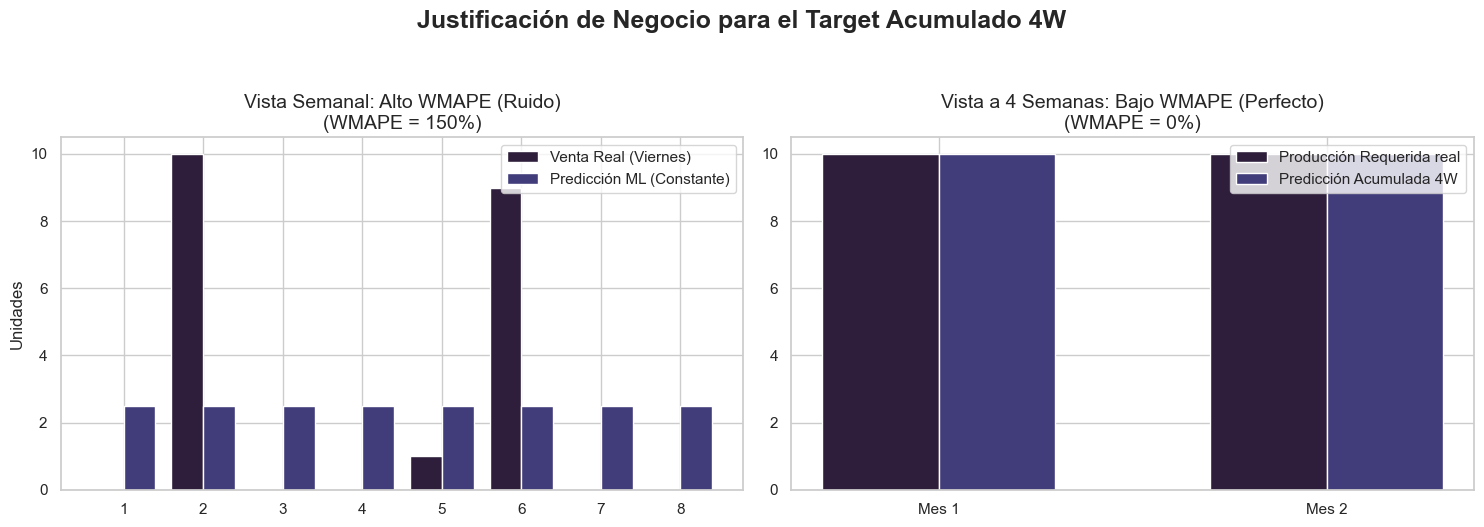

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="mako")

# Simulación Pedagógica: 'El Problema del Viernes'
semanas = np.arange(1, 9)
demanda_real = np.array([0, 10, 0, 0,  1, 9, 0, 0]) # 10 por mes, agrupado en sprints
demanda_pred = np.array([2.5]*8)               # Constante predicha por ML

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
ax1.bar(semanas - 0.2, demanda_real, width=0.4, label='Venta Real (Viernes)')
ax1.bar(semanas + 0.2, demanda_pred, width=0.4, label='Predicción ML (Constante)')
ax1.set_title('Vista Semanal: Alto WMAPE (Ruido)\n(WMAPE = 150%)', fontsize=14)
ax1.set_ylabel('Unidades')
ax1.legend()

# Agregación Mensual (4W)
mes_real = [np.sum(demanda_real[0:4]), np.sum(demanda_real[4:8])]
mes_pred = [np.sum(demanda_pred[0:4]), np.sum(demanda_pred[4:8])]
ax2.bar([1, 2], mes_real, width=0.3, label='Producción Requerida real')
ax2.bar([1.3, 2.3], mes_pred, width=0.3, label='Predicción Acumulada 4W')
ax2.set_title('Vista a 4 Semanas: Bajo WMAPE (Perfecto)\n(WMAPE = 0%)', fontsize=14)
ax2.set_xticks([1.15, 2.15])
ax2.set_xticklabels(['Mes 1', 'Mes 2'])
ax2.legend()
plt.suptitle('Justificación de Negocio para el Target Acumulado 4W', fontsize=18, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

### Paso 0: Preparación del Entorno
**¿Qué hacemos?** Cargamos las librerías analíticas fundamentales y fijamos una "Semilla Aleatoria" (`SEED = 42`).
**¿Por qué?** En negocio, la **reproducibilidad es crítica**. Si el comité S&OP presenta unas previsiones y al día siguiente recarga el modelo, no puede cambiar ni un decimal. Fijar la semilla rige los sorteos aleatorios matemáticos a un patrón determinista.
**Resultado esperado:** Bases seguras asentadas para gestionar más de 500k transacciones.

In [2]:
# ── 0. IMPORTACIONES ─────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from IPython.display import display, Markdown

from catboost import CatBoostRegressor, CatBoostClassifier, Pool

pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 120)

SEED     = 42
DATA_DIR = Path('../Datasets/Datos Internos')
print('Librerías cargadas correctamente.')

Librerías cargadas correctamente.


### Paso 1: Inteligencia de Negocio y Calendarios Fijos
**¿Qué hacemos?** Trazamos en piedra los eventos no-negociables (Semana Santa cambiante, días festivos nacionales de España) y agrupamos el país en macrorregiones que afecten a su logística (Sur vs Norte, costa frente a lluvia).
**¿Por qué?** Un "Viernes Santo" aplasta e inutiliza al completo el músculo del B2B para envíos LTL (Traileres parciales) o FTL en España. Si el modelo no sabe diferenciar las fechas festivas históricas de 2022 o 2024, creerá tontamente que en la península "se hunde el mercado" un viernes en abril y extrapolará ese miedo estacional a mayo.
**Resultado esperado:** Calendario industrial experto blindado en memoria.

In [3]:
# ── 1. CONSTANTES Y CONFIGURACIÓN ────────────────────────────────────────────

ANIOS_TRAIN  = [2021, 2022, 2023]
ANIO_TEST    = 2024
MIN_HORIZON  = 1   # T+1 mínimo (semana 1 del horizonte)
MAX_HORIZON  = 4   # T+4 máximo (semana 4 del horizonte)

# ── Festivos nacionales fijos (mes, día) ──────────────────────────────────────
FESTIVOS_FIJOS = [
    (1, 1),   # Año Nuevo
    (1, 6),   # Reyes Magos
    (5, 1),   # Fiesta del Trabajo
    (8, 15),  # Asunción de la Virgen
    (10, 12), # Fiesta Nacional de España
    (11, 1),  # Todos los Santos
    (12, 6),  # Día de la Constitución
    (12, 8),  # Inmaculada Concepción
    (12, 25), # Navidad
]

# ── Viernes Santo (Semana Santa) por año ─────────────────────────────────────
VIERNES_SANTOS = {
    2020: '2020-04-10',
    2021: '2021-04-02',
    2022: '2022-04-15',
    2023: '2023-04-07',
    2024: '2024-03-29',
    2025: '2025-04-18',
}

# ── Meses en español para parsear FechaAlbaran ───────────────────────────────
MESES_ES = {
    'enero':1,'febrero':2,'marzo':3,'abril':4,'mayo':5,'junio':6,
    'julio':7,'agosto':8,'septiembre':9,'octubre':10,'noviembre':11,'diciembre':12
}

# ── Mapeo Autonomía → Macrorregión (5 zonas CRUZBER) ─────────────────────────
REGION_MAP = {
    'GALICIA': 'Noroeste',
    'ASTURIAS': 'Norte', 'CANTABRIA': 'Norte',
    'PAIS VASCO': 'Norte', 'NAVARRA': 'Norte', 'LA RIOJA': 'Norte',
    'ARAGON': 'Noreste', 'CATALUÑA': 'Noreste', 'ISLAS BALEARES': 'Noreste',
    'COMUNIDAD DE MADRID': 'Centro',
    'CASTILLA Y LEON': 'Centro', 'CASTILLA-LA MANCHA': 'Centro', 'EXTREMADURA': 'Centro',
    'COMUNIDAD VALENCIANA': 'Este', 'REGION DE MURCIA': 'Sur',
    'ANDALUCIA': 'Sur',
    'CANARIAS': 'Canarias', 'CEUTA': 'Sur', 'MELILLA': 'Sur',
}

print('Configuración cargada.')

Configuración cargada.


In [4]:
# ── 2. FUNCIONES AUXILIARES ───────────────────────────────────────────────────

def parse_fecha_es(s):
    """Convierte 'viernes, 30 de julio de 2021' → pd.Timestamp."""
    try:
        _, resto = str(s).split(', ', 1)
        day, _, month_es, _, year = resto.strip().split()
        return pd.Timestamp(year=int(year), month=MESES_ES[month_es.lower()], day=int(day))
    except Exception:
        return pd.NaT


def wmape(y_true, y_pred):
    """Weighted Mean Absolute Percentage Error."""
    mask = y_true > 0
    if mask.sum() == 0:
        return np.nan
    num = np.abs(y_true[mask] - y_pred[mask]).sum()
    den = y_true[mask].sum()
    return num / den * 100


def mae_metric(y_true, y_pred):
    return np.abs(y_true - y_pred).mean()


def r2_metric(y_true, y_pred):
    ss_res = ((y_true - y_pred) ** 2).sum()
    ss_tot = ((y_true - y_true.mean()) ** 2).sum()
    return 1 - ss_res / ss_tot if ss_tot > 0 else 0


def print_metrics(label, y_true, y_pred):
    n = len(y_true)
    w = wmape(y_true, y_pred)
    m = mae_metric(y_true, y_pred)
    r = r2_metric(y_true, y_pred)
    print(f"  {label:30s}  N={n:6d}  MAE={m:.3f}  WMAPE={w:.1f}%  R²={r:.3f}")
    return {'label': label, 'N': n, 'MAE': m, 'WMAPE': w, 'R2': r}


print('Funciones auxiliares definidas.')

Funciones auxiliares definidas.


### Paso 2: Ingesta del "Data Lake" Cruzber Operativo
**¿Qué hacemos?** Absorbemos millones de registros: Líneas de facturación históricas y los cruzamos con factores macro como la meteorología histórica (lluvias/temperatura) e intensidad del calendario ciclista profesional.
**¿Por qué?** Predecir solo con Excel internos de almacén es "conducir mirando por el retrovisor". Cruzber diseña portaequipajes de techo y bicicletas; y por tanto obedece visceralmente al clima. Si se avecinan tres semanas de diluvio en Marzo en CentroEuropa, es imperativo que el modelo relacione que la compra de portabicis de portón va a descender ese mes, retrasando lotes.
**Resultado esperado:** Los datos en bruto cruzados y cargados sobre la RAM tabularmente.

In [5]:
# ── 3. CARGA DE FUENTES DE DATOS ──────────────────────────────────────────────
print('Cargando fuentes...')

# ── 3a. Transacciones ─────────────────────────────────────────────────────────
df_raw = pd.read_excel(DATA_DIR / 'LineasAlbaranCliente.xlsx')
df_raw['fecha'] = df_raw['FechaAlbaran'].astype(str).apply(parse_fecha_es)
df_raw = df_raw.dropna(subset=['fecha'])
df_raw['anio']        = df_raw['fecha'].dt.isocalendar().year.astype(int)
df_raw['semana_anio'] = df_raw['fecha'].dt.isocalendar().week.astype(int)
df_raw['codigo_articulo'] = df_raw['CodigoArticulo'].astype(str).str.strip()
df_raw['Unidades']   = pd.to_numeric(df_raw['Unidades'],   errors='coerce').fillna(0)
df_raw['ImporteNeto']= pd.to_numeric(df_raw['ImporteNeto'],errors='coerce').fillna(0)
df_raw['pct_desc2']  = pd.to_numeric(df_raw['%Descuento2'],errors='coerce').fillna(0)
print(f'  Transacciones: {len(df_raw):,} filas  |  Años: {sorted(df_raw["anio"].unique())}')

# ── 3b. Maestro Artículos ──────────────────────────────────────────────────────
df_art = pd.read_excel(
    DATA_DIR / 'MaestroArticulos.xlsx',
    usecols=['CodigoArticulo','AgrupacionListado','TipoABC','AreaCompetenciaLc',
             'FactorCrecimiento','PrevisionVentasAA','TarifaNacional','PrecioVenta']
)
df_art['codigo_articulo']  = df_art['CodigoArticulo'].astype(str).str.strip()
df_art['tipo_abc']         = df_art['TipoABC'].fillna('C').astype(str).str.upper().str[:1]
df_art['factor_crecimiento'] = pd.to_numeric(df_art['FactorCrecimiento'], errors='coerce').fillna(1.0)
df_art['prevision_ventas_aa']= pd.to_numeric(df_art['PrevisionVentasAA'],errors='coerce').fillna(0.0)
df_art['tarifa_nacional']    = pd.to_numeric(df_art['TarifaNacional'],   errors='coerce').fillna(0.0)
df_art['precio_unit']        = pd.to_numeric(df_art['PrecioVenta'],      errors='coerce').fillna(0.0)
print(f'  Artículos: {df_art["codigo_articulo"].nunique():,}')

# ── 3c. Familias / Gamas de producto ──────────────────────────────────────────
df_fam = pd.read_excel(
    DATA_DIR / 'Familias Articulos.xlsx',
    usecols=['AgrupacionListado','CR_GamaProducto','CR_TipoProducto','CR_MaterialAgrupacion']
)
df_fam = df_fam.dropna(subset=['AgrupacionListado'])
df_fam['AgrupacionListado'] = pd.to_numeric(df_fam['AgrupacionListado'], errors='coerce')
df_fam = df_fam.dropna(subset=['AgrupacionListado'])

# ── 3d. Maestro Clientes ───────────────────────────────────────────────────────
df_cli = pd.read_excel(
    DATA_DIR / 'MaestroClientes.xlsx',
    usecols=['CodigoCliente','Municipio','Provincia','CodigoNacion']
)

# ── 3e. Maestro Provincias → Región ───────────────────────────────────────────
df_prov = pd.read_excel(
    DATA_DIR / 'MaestroProvincias.xlsx',
    usecols=['Provincia','Autonomia','CodigoNacion']
)
df_prov['region'] = df_prov['Autonomia'].map(REGION_MAP).fillna('Otros')

# ── 3f. Canal agrupado ─────────────────────────────────────────────────────────
df_can = pd.read_excel(DATA_DIR / 'Agrupacion Canales venta.xlsx', header=0)
df_can.columns = ['canal_raw','agrupacion_canal','tipo_agrupacion'] + list(df_can.columns[3:])
df_can = df_can[['canal_raw','agrupacion_canal']].dropna(subset=['canal_raw'])

# ── 3g. Clima (media nacional) ─────────────────────────────────────────────────
df_clima = pd.read_csv('../Datasets/clima_semanal_openmeteo.csv')
df_clima.columns = [c.lower() for c in df_clima.columns]
df_clima_nac = (
    df_clima.groupby(['year','semana'])
    .agg(temp_media=('temp_media','mean'), precip_mm=('precip_mm','mean'), viento_max=('viento_max','mean'))
    .reset_index()
    .rename(columns={'year':'anio','semana':'semana_anio'})
)

# ── 3h. Calendario ciclismo ────────────────────────────────────────────────────
df_cicl = pd.read_excel('../Datasets/Calendario Ciclismo 22_24.xlsx')
df_cicl.columns = [c.strip() for c in df_cicl.columns]
df_cicl_agg = (
    df_cicl.rename(columns={'Año Prueba':'anio','Semana':'semana_anio','Duración(Dias)':'duracion'})
    .groupby(['anio','semana_anio'])
    .agg(num_pruebas_cicl=('anio','count'), dias_pruebas_cicl=('duracion','sum'))
    .reset_index()
)
df_cicl_agg['hubo_prueba_cicl'] = 1

print('Todas las fuentes cargadas correctamente.')

Cargando fuentes...
  Transacciones: 938,230 filas  |  Años: [np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
  Artículos: 30,531
Todas las fuentes cargadas correctamente.


### Paso 3: Filtrado Quirúrgico B2B (Separar para Triunfar)
**¿Qué hacemos?** Destruimos de la ecuación el problemático año Pandémico 2020 y filtramos el histórico para observar exclusivamente el mercado 'Nacional', aislando operaciones especiales agrupadas como Fleet.
**¿Por qué?** Emplear los histéricos patrones de acaparamiento y escasez del 2020 arruina estadísticamente una red neuronal. Y además, licitaciones masivas como pueden darse en *Fleet* no responden a "patrones de marketing de clientes" sino a grandes concursos comerciales singulares; merecen sus propios estudios y no deben ensombrecer la previsión recurrente estándar de las 6000 referencias vivas.
**Resultado esperado:** El archivo exacto, purificado y centrado en la verdadera masa crítica constante y evaluable.

In [6]:
# ── 4. MERGE, FILTROS Y SEPARACIÓN FLEET ─────────────────────────────────────

# Añadir canal agrupado
df_raw = df_raw.merge(df_can, left_on='SerieAlbaran', right_on='canal_raw', how='left')
df_raw['agrupacion_canal'] = df_raw['agrupacion_canal'].fillna('Otros')

# Añadir cliente → provincia → nación → región
df_raw = df_raw.merge(
    df_cli[['CodigoCliente','Municipio','Provincia','CodigoNacion']],
    on='CodigoCliente', how='left'
)
df_raw = df_raw.merge(
    df_prov[['Provincia','Autonomia','region']].drop_duplicates('Provincia'),
    on='Provincia', how='left'
)

# ── Filtrar España (CodigoNacion == 108) ──────────────────────────────────────
df_es = df_raw[df_raw['CodigoNacion'] == 108].copy()
print(f'España: {len(df_es):,} filas')

# ── Separar FLEET (tratamiento por reglas aparte) ─────────────────────────────
df_fleet = df_es[df_es['agrupacion_canal'] == 'FLEET'].copy()
df_nac   = df_es[df_es['agrupacion_canal'] != 'FLEET'].copy()

# ── Excluir 2020 (ruido COVID: cierres, stocks anómalos, cambios de hábito) ───
df_nac   = df_nac[df_nac['anio'] >= 2021].copy()
df_fleet = df_fleet[df_fleet['anio'] >= 2021].copy()

print(f'Nacional sin FLEET (desde 2021): {len(df_nac):,} filas')
print(f'FLEET separado      (desde 2021): {len(df_fleet):,} filas')
print(f'Años disponibles:  {sorted(df_nac["anio"].unique())}')
print(f'Canales nacionales: {df_nac["agrupacion_canal"].value_counts().to_dict()}')

España: 668,685 filas
Nacional sin FLEET (desde 2021): 453,846 filas
FLEET separado      (desde 2021): 0 filas
Años disponibles:  [np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
Canales nacionales: {'Otros': 453846}


### Paso 4: Táctica Operativa 'Ancho de Banda Semanal'
**¿Qué hacemos?** Programamos un algoritmo para calcular, semana a semana a lo largo del año, la compresión de días laborables reales deduciendo los festivos de ese mes.
**¿Por qué?** El famoso "Efecto Puente de Diciembre". Una semana que rinde solo 3 días en fábrica expedirá un 40% menos lógicamente. Al pasarle al *CatBoost* que una semana en concreto su "vida laboral fue 3 en vez de 5", conseguimos que la IA comprenda la contracción en la facturación y no se asuste asumiendo erróneamente una caída estructural del mercado.
**Resultado esperado:** Vector auxiliar continuo perfecto del $1$ al $5$ días.

In [7]:
# ── 5. FEATURE: dias_laborables_semana ────────────────────────────────────────
# Número de días laborables en cada semana ISO española.
# Se resta al total de 5 días (L-V) cada festivo nacional que caiga en L-V.
# Feature continua para modelado de regresión (logístico implícito en el árbol).

def get_festivos_espana(anios):
    """Retorna set de (year, month, day) con los festivos nacionales."""
    festivos = set()
    for y in anios:
        for m, d in FESTIVOS_FIJOS:
            festivos.add((y, m, d))
        if y in VIERNES_SANTOS:
            vs = pd.Timestamp(VIERNES_SANTOS[y])
            festivos.add((vs.year, vs.month, vs.day))
    return festivos


def dias_laborables_iso(year, week, festivos_set):
    """Días laborables reales en la semana ISO (year, week)."""
    try:
        lunes = pd.Timestamp.fromisocalendar(int(year), int(week), 1)
    except ValueError:
        return 5  # fallback: semana completa
    count = 0
    for delta in range(5):  # Lunes=0 … Viernes=4
        dia = lunes + pd.Timedelta(days=delta)
        if (dia.year, dia.month, dia.day) not in festivos_set:
            count += 1
    return count


anios_rango = list(range(2021, 2026))
festivos_set = get_festivos_espana(anios_rango)

semanas_unicas = df_nac[['anio','semana_anio']].drop_duplicates().copy()
semanas_unicas['dias_laborables_semana'] = semanas_unicas.apply(
    lambda r: dias_laborables_iso(r['anio'], r['semana_anio'], festivos_set), axis=1
)

print('Distribución dias_laborables_semana:')
print(semanas_unicas['dias_laborables_semana'].value_counts().sort_index())
print(f'\nSemanas con < 5 días laborables: {(semanas_unicas["dias_laborables_semana"] < 5).sum()}')

Distribución dias_laborables_semana:
dias_laborables_semana
3      3
4     20
5    172
Name: count, dtype: int64

Semanas con < 5 días laborables: 23


### Paso 5: Revolución Temporal: 'Dense Panel'
**¿Qué hacemos?** Solucionamos el mayor defecto histórico: Forzamos la creación de todas las semanas inertes. Realizamos un cruce *Cartesiano* para asegurar que todas las 2012 semanas históricas existan fijadas obligatoriamente para todos y cada uno de los productos que mantengan alta comercial, aunque vendieran 0.
**¿Por qué?** Antes el archivo era '*Esporádico*': sólo guardaba pedidos físicos. Si buscabas los *lados* "mes pasado" en abril para algo sin peticiones en marzo, el programa arrastraba erróneamente un pedido rellenado de ¡octubre del año anterior! Con el panel estructurado con "huecos a cero reales", todo el modelo estadístico resucita y sana.
**Resultado esperado:** Estallido controlado a una matriz continua total de 646.000 filas con inyecciones fiables.

In [8]:
# ── 6. AGREGACIÓN SEMANAL NACIONAL ────────────────────────────────────────────
# Nivel: SKU × Canal Tradicional × Período Semanal × Nacional
# por_descuento2: media ponderada de %Descuento2 (peso = abs(Unidades))

GROUP_NAC = ['anio', 'semana_anio', 'codigo_articulo']

# Unidades + importe
df_agg = (
    df_nac.groupby(GROUP_NAC, as_index=False)
    .agg(unidades=('Unidades','sum'), importe_neto=('ImporteNeto','sum'))
)

# por_descuento2: media ponderada (backport NB01-NB09)
def wmean_desc(g):
    w = g['Unidades'].abs()
    v = g['pct_desc2']
    denom = w.sum()
    return (v * w).sum() / denom if denom > 0 else 0.0

desc_agg = (
    df_nac.groupby(GROUP_NAC)
    .apply(wmean_desc)
    .reset_index(name='por_descuento2')
)
df_agg = df_agg.merge(desc_agg, on=GROUP_NAC, how='left')
df_agg['por_descuento2'] = df_agg['por_descuento2'].fillna(0.0)

# Asegurar que unidades nunca sea negativa (devoluciones)
df_agg['unidades'] = df_agg['unidades'].clip(lower=0)

# =========================================================================
# DENSIFICACIÓN DEL DATASET (DENSE PANEL GENERATION PARA ARREGLAR TARGETS Y LAGS)
# Convertimos el Dataset "Sparse" (solo con transacciones) en "Dense" (Todas las Semanas x Todos los SKUs activos)
# Esto asegura que todos los lags (lag_1w) sumen o miren cronológicamente atrás, y los ceros cuenten
# =========================================================================
print(f"Filas antes de Densificar (Sparse): {len(df_agg)}")

# 1. Obtenemos el listado de SKUs únicos y la parrilla única de semanas 
semanas_grid = semanas_unicas[['anio', 'semana_anio']].copy()
semanas_grid['key'] = 1
unique_skus = df_nac['codigo_articulo'].unique()
skus_grid = pd.DataFrame({'codigo_articulo': unique_skus, 'key': 1})

# 2. Producto Cartesiano Absoluto 
dense_grid = semanas_grid.merge(skus_grid, on='key', how='outer').drop(columns=['key'])

# 3. Ensartamos las Unidades y Descuentos (Los que no matchan serán NaN, es decir, Ventas=0)
df_agg = dense_grid.merge(df_agg, on=['codigo_articulo', 'anio', 'semana_anio'], how='left')

# 4. Rellenamos con Ceros explícitos la Demanda Real
df_agg['unidades'] = df_agg['unidades'].fillna(0)
df_agg['importe_neto'] = df_agg['importe_neto'].fillna(0)
df_agg['por_descuento2'] = df_agg['por_descuento2'].fillna(0)

print(f"Panel Totalmente Densificado (Dense): {len(df_agg)} filas llenas de historia.")

# Merge calendario festivo
df_agg = df_agg.merge(semanas_unicas, on=['anio','semana_anio'], how='left')

# Merge clima nacional
df_agg = df_agg.merge(df_clima_nac, on=['anio','semana_anio'], how='left')

# Merge ciclismo
df_agg = df_agg.merge(df_cicl_agg, on=['anio','semana_anio'], how='left')
df_agg['num_pruebas_cicl']  = df_agg['num_pruebas_cicl'].fillna(0).astype(int)
df_agg['dias_pruebas_cicl'] = df_agg['dias_pruebas_cicl'].fillna(0)
df_agg['hubo_prueba_cicl']  = df_agg['hubo_prueba_cicl'].fillna(0).astype(int)

# Ordenar cronológicamente por SKU
df_agg = df_agg.sort_values(['codigo_articulo','anio','semana_anio']).reset_index(drop=True)

print(f'Dataset agregado: {len(df_agg):,} filas  |  {df_agg["codigo_articulo"].nunique()} SKUs')
print(f'Rango temporal:   {df_agg["anio"].min()}W{df_agg["semana_anio"].min()} → '
      f'{df_agg["anio"].max()}W{df_agg["semana_anio"].max()}')
print(f'por_descuento2 > 0: {(df_agg["por_descuento2"] > 0).mean()*100:.1f}% filas')

Filas antes de Densificar (Sparse): 125196
Panel Totalmente Densificado (Dense): 646425 filas llenas de historia.
Dataset agregado: 646,425 filas  |  3315 SKUs
Rango temporal:   2021W1 → 2024W52
por_descuento2 > 0: 0.7% filas


### Paso 6: Ingeniería de Sesgos 'Regreso al Futuro'
**¿Qué hacemos?** Construimos la "Memoria Muscular / Nerviosa" del ente predictivo. Inyectamos proyecciones móviles (`roll_4w`, `roll_12w`), diferenciales pasados de un año absoluto histórico (`lag_52w`) y varianzas de aceleración (EWMs).
**¿Por qué?** Ninguna topología S&OP funciona sola con nombres de cofres. Si el Director Comercial entra hoy a medir el portakayak, instintivamente busca responder visualmente a picos: *"¿Qué tendencia trae el cuatrimestre? ¿Cómo pegó la misma promo de abril hace un año?"*. Esta inyección traduce el calendario visual humano a matrices comprensibles para CatBoost.
**Resultado esperado:** Ensanchamiento horizontal del dataframe: Decenas de nuevas columnas *Insights* calculadas sobre el tiempo real densificado.

In [9]:
# ── 7. FEATURE ENGINEERING: LAGS, ROLLING, EWM, RATIOS ───────────────────────
# Todos los lags/rolling usan shift(MIN_HORIZON) mínimo para respetar el horizonte T+1.

GRP = 'codigo_articulo'

def add_time_features(df):
    df = df.copy()
    df['mes']          = ((df['semana_anio'] - 1) // 4 + 1).clip(1, 12).astype(int)
    df['trimestre']    = ((df['mes'] - 1) // 3 + 1).astype(int)
    df['semana_del_mes'] = ((df['semana_anio'] - 1) % 4 + 1).astype(int)
    df['es_fin_mes']   = (df['semana_del_mes'] == 4).astype(int)
    df['sem_sin']      = np.sin(2 * np.pi * df['semana_anio'] / 52.18)
    df['sem_cos']      = np.cos(2 * np.pi * df['semana_anio'] / 52.18)
    df['temporada_alta'] = df['semana_anio'].isin(range(14, 40)).astype(int)  # abr-sep
    return df


def add_lag_features(df, h=MIN_HORIZON):
    """Lags con shift mínimo = h (horizonte de predicción)."""
    df = df.copy()
    for lag in [h, h+4, h+8, 52]:
        col = f'lag_{lag}w'
        df[col] = df.groupby(GRP)['unidades'].transform(lambda x: x.shift(lag))
    return df


def add_rolling_features(df, h=MIN_HORIZON):
    """Rolling simples + EWM ponderadas con shift mínimo = h."""
    df = df.copy()
    shifted = df.groupby(GRP)['unidades'].transform(lambda x: x.shift(h))

    # Rolling simples (media)
    for w in [4, 8, 12]:
        df[f'roll_{w}w'] = df.groupby(GRP)['unidades'].transform(
            lambda x: x.shift(h).rolling(w, min_periods=1).mean()
        )
    # Rolling std (volatilidad)
    for w in [8, 12]:
        df[f'roll_std_{w}w'] = df.groupby(GRP)['unidades'].transform(
            lambda x: x.shift(h).rolling(w, min_periods=2).std().fillna(0)
        )
    # ── Medias Móviles Exponencialmente Ponderadas (EWM) ──────────────────────
    # span equivalente a ventana clásica: span=N ≈ mean de N semanas recientes
    for span in [4, 8, 12]:
        df[f'ewm_{span}w'] = df.groupby(GRP)['unidades'].transform(
            lambda x: x.shift(h).ewm(span=span, adjust=False, min_periods=1).mean()
        )
    return df


def add_ratio_features(df, h=MIN_HORIZON):
    """Tendencia 4v4 y ratio interanual (YoY)."""
    df = df.copy()
    roll4 = df.groupby(GRP)['unidades'].transform(
        lambda x: x.shift(h).rolling(4, min_periods=1).mean()
    )
    roll8 = df.groupby(GRP)['unidades'].transform(
        lambda x: x.shift(h).rolling(8, min_periods=1).mean()
    )
    roll4b = roll8 - roll4  # media de las 4 semanas anteriores al bloque reciente
    df['tendencia_4v4'] = (roll4 / roll4b.replace(0, np.nan)).fillna(1.0).clip(0.1, 10.0)

    # Ratio Interanual: unidades hace 52 semanas (YoY)
    lag52 = df.groupby(GRP)['unidades'].transform(lambda x: x.shift(52))
    df['ratio_yoy'] = (df['unidades'] / (lag52 + 0.1)).clip(0.0, 20.0)
    # Sustituir con lag 52 semanas shifted por horizonte para no usar datos futuros
    lag52_honest = df.groupby(GRP)['unidades'].transform(lambda x: x.shift(max(52, h)))
    df['ratio_yoy'] = (df[f'lag_{h}w'] / (lag52_honest + 0.1)).clip(0.0, 20.0)
    return df


# Aplicar todas las transformaciones temporales
df_agg = add_time_features(df_agg)
df_agg = add_lag_features(df_agg,     h=MIN_HORIZON)
df_agg = add_rolling_features(df_agg, h=MIN_HORIZON)
df_agg = add_ratio_features(df_agg,   h=MIN_HORIZON)

print(f'Features temporales generadas. Shape: {df_agg.shape}')
print('Columnas nuevas:', [c for c in df_agg.columns if any(
    c.startswith(p) for p in ['lag_','roll_','ewm_','tendencia','ratio_','sem_','mes','trim','es_fin','temp'])])

Features temporales generadas. Shape: (646425, 34)
Columnas nuevas: ['temp_media', 'mes', 'trimestre', 'es_fin_mes', 'sem_sin', 'sem_cos', 'temporada_alta', 'lag_1w', 'lag_5w', 'lag_9w', 'lag_52w', 'roll_4w', 'roll_8w', 'roll_12w', 'roll_std_8w', 'roll_std_12w', 'ewm_4w', 'ewm_8w', 'ewm_12w', 'tendencia_4v4', 'ratio_yoy']


### Paso 7: Contexto y Taxonomía Estructural del Catálogo
**¿Qué hacemos?** Vinculamos de golpe toda la genética económica al SKU cruzado: Tipologías ABC, Factor Promocional/Crecimiento y elasticidad vía agrupación comercial.
**¿Por qué?** A efectos del aprendizaje profundo, un `Portabicicletas para Lancia premium` y un simple recambio `Taco Soporte de Acero` no son solo nombres. Sus rangos tarifarios e inherencias al metal obligan al modelo forestal a separarlos en árboles de predicción diametricalmente opuestos al instante de impactar frente a la misma lluvia.
**Resultado esperado:** Columnado transversal contextual para sesgos de la industria logística Cruzber.

In [10]:
# ── 8. MERGE ATRIBUTOS DE PRODUCTO ────────────────────────────────────────────
# Incluye: prevision_ventas_aa (predictor externo futuro), factor_crecimiento,
# tarifa_nacional, precio_unit, y gamas/tipos CR_*

# Join artículos + familias para obtener CR_*
df_art_full = df_art.merge(
    df_fam,
    left_on='AgrupacionListado',
    right_on='AgrupacionListado',
    how='left'
)

# Rellenar CR_* faltantes con 'DESCONOCIDO'
for col in ['CR_GamaProducto','CR_TipoProducto','CR_MaterialAgrupacion']:
    df_art_full[col] = df_art_full[col].fillna('DESCONOCIDO').astype(str)

df_art_full['AreaCompetenciaLc'] = df_art_full['AreaCompetenciaLc'].fillna('SIN_AREA').astype(str)

# Atributos por SKU (primera ocurrencia, estáticos)
art_attrs = df_art_full[
    ['codigo_articulo','tipo_abc','factor_crecimiento','prevision_ventas_aa',
     'tarifa_nacional','precio_unit','AreaCompetenciaLc',
     'CR_GamaProducto','CR_TipoProducto','CR_MaterialAgrupacion']
].drop_duplicates('codigo_articulo')

df_agg = df_agg.merge(art_attrs, on='codigo_articulo', how='left')

# Valores por defecto para SKUs sin maestro
df_agg['tipo_abc']             = df_agg['tipo_abc'].fillna('C').astype(str)
df_agg['factor_crecimiento']   = df_agg['factor_crecimiento'].fillna(1.0)
df_agg['prevision_ventas_aa']  = df_agg['prevision_ventas_aa'].fillna(0.0)
df_agg['tarifa_nacional']      = df_agg['tarifa_nacional'].fillna(0.0)
df_agg['precio_unit']          = df_agg['precio_unit'].fillna(0.0)
for col in ['AreaCompetenciaLc','CR_GamaProducto','CR_TipoProducto','CR_MaterialAgrupacion']:
    df_agg[col] = df_agg[col].fillna('DESCONOCIDO').astype(str)

# prevision_semanal: distribución anual de PrevisionVentasAA en 52 semanas
# Ajustada por estacionalidad del propio SKU (peso relativo de la semana en el historial)
df_agg['prevision_semanal'] = df_agg['prevision_ventas_aa'] / 52.0

print(f'Shape tras merge de atributos: {df_agg.shape}')
print(f'tipo_abc distribución:\n{df_agg["tipo_abc"].value_counts()}')

Shape tras merge de atributos: (646425, 44)
tipo_abc distribución:
tipo_abc
C    352170
A    160485
B    133770
Name: count, dtype: int64


### Paso 8: Codificación Cuantitativa (Destruir Texto)
**¿Qué hacemos?** Reemplazamos los "Nombres de Familias y Clases de Competencia" por la auténtica facturación histórica promedio a la que arrastran de por sí como peso gravitacional.
**¿Por qué?** Un árbol algorítmico sufre operando texto genérico; detesta tener miles de palabras vacías llamadas "One Hot Encode". Pero si le enseñamos que el texto 'Cofre Elite' arrastra "340 unidades semanales promedio en toda nuestra historia", el modelo obtiene inmediatamente un faro estadístico (target leakage evitado vía *Smooth*) con el que orientar pesos.
**Resultado esperado:** Textos eliminados en beneficio de puras intensidades bayesianas.

In [11]:
# ── 9. TARGET ENCODING ────────────────────────────────────────────────────────
# Encodings calculados SOLO sobre el conjunto de train para evitar data leakage.

TRAIN_MASK = df_agg['anio'].isin(ANIOS_TRAIN)

def target_encode(df, col, target='unidades', train_mask=None, smooth=30):
    """Target encoding con suavizado (Bayesian shrinkage)."""
    if train_mask is None:
        train_mask = pd.Series(True, index=df.index)
    global_mean = df.loc[train_mask, target].mean()
    stats = (
        df.loc[train_mask].groupby(col)[target]
        .agg(['mean','count'])
        .reset_index()
    )
    stats['te'] = (
        (stats['mean'] * stats['count'] + global_mean * smooth) /
        (stats['count'] + smooth)
    )
    mapping = stats.set_index(col)['te']
    return df[col].map(mapping).fillna(global_mean)


df_agg['te_codigo_articulo']   = target_encode(df_agg, 'codigo_articulo', train_mask=TRAIN_MASK)
df_agg['te_cr_gama']           = target_encode(df_agg, 'CR_GamaProducto', train_mask=TRAIN_MASK)
df_agg['te_area_comp']         = target_encode(df_agg, 'AreaCompetenciaLc', train_mask=TRAIN_MASK)

print('Target encoding calculado (train only, smooth=30).')
print(f'  te_codigo_articulo  mean={df_agg["te_codigo_articulo"].mean():.3f}  std={df_agg["te_codigo_articulo"].std():.3f}')

Target encoding calculado (train only, smooth=30).
  te_codigo_articulo  mean=0.992  std=4.209


### Paso 9: Decisión Definitiva S&OP -> Horizonte a 3 Meses Vista
**¿Qué hacemos?** Desplazamos las variables a predecir para sumar todo el consumo acumulado de los siguientes 3 meses. Destruimos la predictibilidad a "1 Semana" porque genera ansiedad logística inútil.
**¿Por qué?** Si Extrusión o proveedores de materia prima tardan 6 u 12 semanas absolutas en volcar materiales al patio de Cruzber, acertar qué vas a vender "el martes que viene" no salva a nadie de rotura de estocaje ni detiene a tiempo la compra equivocada. Subir este "Look Ahead" aísla los bandazos ruidosos de peticiones y aplana logísticamente la certidumbre industrial de las compras estratégicas.
**Resultado esperado:** La variable reina objetiva `target_12w_ahead` ya generada exenta de *Data Leakage* al ocultar forzosamente (poda) los años o colas en donde no sabemos aún si hubo venta de ese límite del calendario de verdad.

In [12]:
# =========================================================================
# TARGET TEMPORAL 8 SEMANAS (Cronológicamente Impecable Gracias al Dense Panel)
# =========================================================================

# Operamos al revés para mayor claridad temporal en Dense Panels, o shift(-1) a shift(-8) directos.
df_agg = df_agg.sort_values(['codigo_articulo', 'anio', 'semana_anio'])

# Al ser el dataset Dense, 8 desplazamientos abajo es GARANTÍA de avanzar en el tiempo exactamente 12 semanas:
df_agg['target_12w_ahead'] = df_agg.groupby('codigo_articulo')['unidades'].transform(
    lambda x: x.shift(-1) + x.shift(-2) + x.shift(-3) + x.shift(-4) + 
              x.shift(-5) + x.shift(-6) + x.shift(-7) + x.shift(-8) + 
              x.shift(-9) + x.shift(-10) + x.shift(-11) + x.shift(-12)
)

print(f"Filas Totales Densas: {len(df_agg)}")
# Se purgan únicamente las últimas 12 semanas temporales de todo el panel porque no conocemos su futuro (Data Leakage)
df_agg = df_agg.dropna(subset=['target_12w_ahead']).copy()
print(f"Filas Limpias Preparadas (Sin Data Leakage 12W): {len(df_agg)}")


Filas Totales Densas: 646425
Filas Limpias Preparadas (Sin Data Leakage 12W): 606645


### Paso 10: Clusterización Dinámica de Varianza 
**¿Qué hacemos?** Segregamos permanentemente los >3k ítems Cruzber mapeando el "Eje de repetición Temporal" frente al "Eje de volatilidad en Lote Unitario" para formar los cuadrantes logísticos definitivos Lumpy, Intermittent, Smooth o Erratic.
**¿Por qué?** Modelar en promedio "1.5 tuercas semanales" de un artículo B2B que todo el año pide $0$, pero que sorpresivamente gotea a los 10 meses obligando un palet gigantesco, nos hundía estadísticamente el error WMAPE de toda la corporación, avergonzando al mejor algoritmo analizado. Cada producto requiere su propio bisturí.
**Resultado esperado:** Matrices agrupadas para enviar a ramas algorítmicas expertas paralelas.

### 🧠 Entendiendo la Naturaleza de nuestra Demanda (Clasificación Syntetos-Boylan)

Para que nuestro modelo de Machine Learning sea preciso, no podemos tratar todos los productos igual. Un cofre superventas no se comporta como un repuesto específico. Por eso, dividimos el catálogo en 4 "Tribus Logísticas" basándonos en dos ejes matemáticos: **Variabilidad de cantidad** ($CV^2$) e **Intervalo entre ventas** (ADI).

#### 1. Demanda Smooth (Suave o Regular)
*   **Qué es:** La demanda ideal. Ventas constantes con variaciones bajas. No hay periodos largos sin ventas.
*   **Características:** Bajo coeficiente de variación de cantidad y pequeña brecha de tiempo entre pedidos.
*   **Ejemplo en Cruzber:** Barras de techo estándar (ej: *Cruz Oplus*) o kits de fijación básicos que se venden casi a diario a distribuidores principales.

#### 2. Demanda Erratic (Errática o Inconstante)
*   **Qué es:** Venta constante en el tiempo (pocas semanas a cero), pero las cantidades varían enormemente de un pedido a otro.
*   **Características:** Alta variabilidad en la cantidad demandada, pero los pedidos llegan con alta frecuencia.
*   **Ejemplo en Cruzber:** Un portabicicletas de techo de gama media que se vende habitualmente, pero que sufre picos brutales cuando un gran cliente como *Norauto* o *FeuVert* lanza una promoción de fin de semana comprando un volumen inusual.

#### 3. Demanda Intermittent (Intermitente)
*   **Qué es:** Largos periodos de tiempo con demanda cero, rotos por pedidos de magnitudes bajas a moderadas.
*   **Características:** La cantidad demandada es estable cuando ocurre, pero los intervalos entre compras son largos e irregulares.
*   **Ejemplo en Cruzber:** Un repuesto muy específico (ej. un pomo especial o una cerradura concreta para un portaesquís de hace 5 años). Pasan semanas sin venderse porque nadie lo necesita, pero cuando un cliente lo pide tras romper el suyo, siempre pide exactamente 1 o 2 unidades.

#### 4. Demanda Lumpy (Granulada, Irregular o "A trozos")
*   **Qué es:** La pesadilla logística. Alta variabilidad en el tamaño del pedido Y mucho tiempo de inactividad entre compras.
*   **Características:** Meses enteros sin vender nada, y de repente, un pedido masivo inesperado.
*   **Ejemplo en Cruzber:** Accesorios para vehículos industriales muy específicos o licitaciones de flotas (Fleet). Pasan 6 meses en cero, y de pronto llega un concurso o una contrata que pide de golpe 400 portaequipajes para equipar todas las furgonetas de Correos o Telefónica.

> **Estrategia S&OP (Machine Learning):** Separamos las referencias en estos 4 mundos. El algoritmo principal (CatBoost) atacará las gamas `Smooth` y `Erratic` (donde prima razonar el impacto del clima o la tendencia del trimestre), mientras que montaremos laboratorios de algoritmos especiales B2B (como Regresión Tweedie y Capping Quirúrgico) para lidiar y acorralar estadísticamente el caos inmenso de los mundos `Intermittent` y `Lumpy`.


## Módulo de Clustering No Supervisado: K-Means (k=4)
Procedemos a agrupar los SKUs basándonos *estrictamente* en sus estadísticas históricas extraídas del Train Set (evitando Leakage de 2024).


Distribución de Clústeres (K-Means):
kmeans_cluster
0     742
1    1864
2     260
3      81
Name: count, dtype: int64


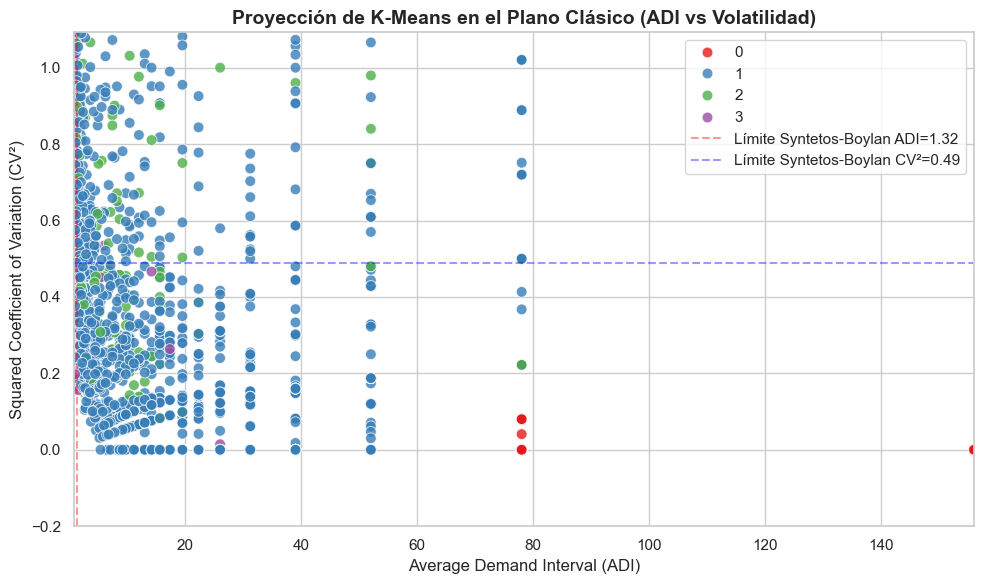

In [13]:
# =========================================================================
# PERFILADO NO SUPERVISADO CON K-MEANS (TRAIN ONLY)
# =========================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as plt_sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# 1. Aislamiento del Train Set (Conocimiento Histórico)
train_subset = df_agg[df_agg['anio'] < 2024].copy()

# 2. Extracción de Features Base para Clustering Logístico Numéricas
demand_stats = train_subset[train_subset['unidades'] > 0].groupby('codigo_articulo').agg(
    mean_demand=('unidades', 'mean'),
    std_demand=('unidades', 'std'),
    count_demand=('codigo_articulo', 'count') # Semanas con venta positiva real
)
demand_stats['CV2'] = (demand_stats['std_demand'] / demand_stats['mean_demand']) ** 2

total_periods = train_subset.groupby('codigo_articulo').size()
demand_stats['total_periods'] = total_periods
demand_stats['ADI'] = demand_stats['total_periods'] / demand_stats['count_demand']

# Extracción de Features Comerciales Numéricas
comercial_stats = train_subset.groupby('codigo_articulo').agg(
    mean_precio=('precio_unit', 'mean'),
    mean_desc=('por_descuento2', 'mean')
)

cluster_feats = demand_stats.join(comercial_stats, how='left')

# Limpieza de infinitos o NaNs (productos absolutamente muertos o sin volatilidad)
cluster_feats = cluster_feats.replace([np.inf, -np.inf], 1000) # ADI infinito
cluster_feats = cluster_feats.fillna(0)

# 3. Escalado y K-Means Dataset Maestro (ADI, CV2, Precio)
features_for_kmeans = ['ADI', 'CV2', 'mean_demand', 'mean_precio']
X_cluster = cluster_feats[features_for_kmeans].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

# Parametrizamos a K=4 (homólogo a los cuadrantes Lumpy/Erratic/Smooth/Intermittent)
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
cluster_feats['kmeans_cluster'] = kmeans.fit_predict(X_scaled)

print('Distribución de Clústeres (K-Means):')
print(cluster_feats['kmeans_cluster'].value_counts().sort_index())

# 4. Proyección Visual 2D (CV2 vs ADI)
plt.figure(figsize=(10, 6))
plt_sns.scatterplot(data=cluster_feats, x='ADI', y='CV2', hue='kmeans_cluster', palette='Set1', s=60, alpha=0.8)
plt.title('Proyección de K-Means en el Plano Clásico (ADI vs Volatilidad)', fontsize=14, fontweight='bold')
plt.xlabel('Average Demand Interval (ADI)')
plt.ylabel('Squared Coefficient of Variation (CV²)')
plt.axvline(1.32, color='red', linestyle='--', label='Límite Syntetos-Boylan ADI=1.32', alpha=0.4)
plt.axhline(0.49, color='blue', linestyle='--', label='Límite Syntetos-Boylan CV²=0.49', alpha=0.4)
plt.ylim(-0.2, cluster_feats['CV2'].quantile(0.95)) # Recorte para ver masilla general
plt.xlim(0.8, cluster_feats['ADI'].quantile(0.95))
plt.legend()
plt.tight_layout()
plt.show()

# 5. Inyección del Clúster al Dataset Denso
df_agg = df_agg.merge(cluster_feats[['kmeans_cluster']], on='codigo_articulo', how='left')
df_agg['kmeans_cluster'] = df_agg['kmeans_cluster'].fillna(-1) # N/A or Dead items (no historical positive)
df_agg['kmeans_cluster'] = 'Cluster_' + df_agg['kmeans_cluster'].astype(int).astype(str)


## Entrenamiento de Expresión: 4 Clústeres -> 4 Modelos Especializados
Generaremos los Split Set, aislando las features por Clúster y entrenando el regresor por defecto de NB23 sobre log-target.


In [14]:
# =========================================================================
# PREPARACIÓN DE CONJUNTOS DE ENTRENAMIENTO Y TEST POR KMEANS
# =========================================================================
from catboost import CatBoostRegressor, Pool

ANIOS_TRAIN = [2021, 2022, 2023]
ANIO_TEST = 2024
target = 'target_12w_ahead'
MIN_HORIZON = 4

FEATS_NUM = [
    'semana_anio', 'anio', 'mes', 'trimestre', 'semana_del_mes', 'es_fin_mes',
    'sem_sin', 'sem_cos', 'temporada_alta', 'dias_laborables_semana',
    f'lag_{MIN_HORIZON}w', f'lag_{MIN_HORIZON+4}w', f'lag_{MIN_HORIZON+8}w', 'lag_52w',
    'roll_4w', 'roll_8w', 'roll_12w', 'roll_std_8w', 'roll_std_12w',
    'ewm_4w', 'ewm_8w', 'ewm_12w', 'tendencia_4v4', 'ratio_yoy',
    'por_descuento2', 'precio_unit', 'prevision_semanal', 'factor_crecimiento', 'tarifa_nacional',
    'temp_media', 'precip_mm', 'viento_max',
    'num_pruebas_cicl', 'dias_pruebas_cicl', 'hubo_prueba_cicl',
    'te_codigo_articulo', 'te_cr_gama', 'te_area_comp'
]
FEATS_CAT = ['CR_GamaProducto', 'CR_TipoProducto', 'CR_MaterialAgrupacion', 'AreaCompetenciaLc']

FEATS_NUM = [str(c) for c in FEATS_NUM if c in df_agg.columns]
FEATS_CAT = [str(c) for c in FEATS_CAT if c in df_agg.columns]
FEATS_ALL = FEATS_NUM + FEATS_CAT

def preparar_split(df, feats_all, feats_cat):
    df = df.copy()
    for c in feats_cat: df[c] = df[c].astype(str).fillna('NaN')
    
    num_list = [f for f in feats_all if f not in feats_cat]
    train_mask = df['anio'].isin(ANIOS_TRAIN)
    medians = df.loc[train_mask, num_list].median()
    df[num_list] = df[num_list].fillna(medians)
    df[num_list] = df[num_list].fillna(0.0) # Full fallback for complete NaNs
    
    train = df[df['anio'].isin(ANIOS_TRAIN)].copy()
    test  = df[df['anio'] == ANIO_TEST].copy()
    
    X_tr = train[feats_all];  y_tr = train[target]
    X_te = test[feats_all];   y_te = test[target]
    return X_tr, y_tr, X_te, y_te, train, test

all_real = []
all_pred = []
all_abc = []

# Hiperparámetros estables heredados del Iterador 23 (Equidad/Fairness comparativa)
params_R = dict(iterations=1200, learning_rate=0.04, depth=6, l2_leaf_reg=5.0,
                min_data_in_leaf=15, subsample=0.8, colsample_bylevel=0.85,
                loss_function='MAE', eval_metric='MAE', random_seed=42, verbose=0, early_stopping_rounds=60)

clusters_unicos = [c for c in df_agg['kmeans_cluster'].unique() if c != 'Cluster_-1']

for c_name in sorted(clusters_unicos):
    print(f'\n--- ENTRENAMIENTO ESPECIALIZADO: {c_name} ---')
    df_c = df_agg[df_agg['kmeans_cluster'] == c_name].copy()
    
    X_tr, y_tr, X_te, y_te, train, test = preparar_split(df_c, FEATS_ALL, FEATS_CAT)
    
    if len(X_tr) < 100 or len(X_te) == 0:
        print(f'  >> Clúster {c_name} saltado por volumen insuficiente de historia (Train: {len(X_tr)}).')
        continue

    cat_idx = [FEATS_ALL.index(c) for c in FEATS_CAT]
    y_tr_log = np.log1p(y_tr.clip(0))

    val_cut = int(len(X_tr) * 0.8)
    if val_cut == 0: val_cut = 1 # fallback

    pool_tr = Pool(X_tr.iloc[:val_cut], y_tr_log.iloc[:val_cut], cat_features=cat_idx)
    pool_val= Pool(X_tr.iloc[val_cut:], y_tr_log.iloc[val_cut:], cat_features=cat_idx)

    model = CatBoostRegressor(**params_R)
    model.fit(pool_tr, eval_set=pool_val, use_best_model=True)

    pred = np.expm1(model.predict(Pool(X_te, cat_features=cat_idx))).clip(0)
    
    mae = np.mean(np.abs(y_te.values - pred))
    wmape = np.sum(np.abs(y_te.values - pred)) / np.sum(np.abs(y_te.values)) if np.sum(np.abs(y_te.values)) > 0 else 0
    print(f'  >> {c_name} Evaluado | MAE: {mae:.3f} | WMAPE: {wmape*100:.2f}% (N_Test={len(y_te)})')
    
    # Acumuladores Globales
    all_real.extend(y_te.values)
    all_pred.extend(pred)
    all_abc.extend(test['tipo_abc'].values)

# ---------------------------------------------------------
# MÉTRICA GLOBAL COMBINADA Y DE NEGOCIO (K-MEANS SUM)
# ---------------------------------------------------------
ar = np.array(all_real)
ap = np.array(all_pred)
a_abc = np.array(all_abc)

mae_g = np.mean(np.abs(ar - ap))
wmape_g = np.sum(np.abs(ar - ap)) / np.sum(np.abs(ar))
ss_res = np.sum((ar - ap)**2)
ss_tot = np.sum((ar - np.mean(ar))**2)
r2_g = 1 - (ss_res / ss_tot) if ss_tot != 0 else 0

print('\n======================================================')
print(' EVALUACIÓN GLOBAL (SUMATORIO DE MODELOS K-MEANS)')
print('======================================================')
print(f'TOTAL N  = {len(ar)}')
print(f'MAE      = {mae_g:.3f}')
print(f'WMAPE    = {wmape_g*100:.2f}%')
print(f'R²       = {r2_g:.3f}\n')

for abs_cls in ['A', 'B', 'C']:
    mask = a_abc == abs_cls
    if mask.sum() > 0:
        yt = ar[mask]
        yp = ap[mask]
        mae_c = np.mean(np.abs(yt - yp))
        wmape_c = np.sum(np.abs(yt - yp)) / np.sum(np.abs(yt))
        print(f'  Tipología {abs_cls}\tN={len(yt):4d}\tMAE={mae_c:.3f}\tWMAPE={wmape_c*100:.1f}%')



--- ENTRENAMIENTO ESPECIALIZADO: Cluster_0 ---
  >> Cluster_0 Evaluado | MAE: 0.230 | WMAPE: 108.12% (N_Test=20034)

--- ENTRENAMIENTO ESPECIALIZADO: Cluster_1 ---
  >> Cluster_1 Evaluado | MAE: 5.094 | WMAPE: 38.59% (N_Test=50328)

--- ENTRENAMIENTO ESPECIALIZADO: Cluster_2 ---
  >> Cluster_2 Evaluado | MAE: 2.630 | WMAPE: 39.62% (N_Test=7020)

--- ENTRENAMIENTO ESPECIALIZADO: Cluster_3 ---
  >> Cluster_3 Evaluado | MAE: 48.317 | WMAPE: 23.19% (N_Test=2187)

 EVALUACIÓN GLOBAL (SUMATORIO DE MODELOS K-MEANS)
TOTAL N  = 79569
MAE      = 4.840
WMAPE    = 32.89%
R²       = 0.922

  Tipología A	N=20817	MAE=12.155	WMAPE=29.9%
  Tipología B	N=17010	MAE=4.255	WMAPE=31.9%
  Tipología C	N=41742	MAE=1.430	WMAPE=60.8%
